# 📊 EDA: Dataset de Enfermedades y Síntomas

## Objetivo
Analizar el dataset `Final_Augmented_dataset_Diseases_and_Symptoms.csv` para comprender:
- Estructura y dimensiones del dataset
- Distribución de enfermedades
- Frecuencia de síntomas
- Correlaciones entre síntomas
- Síntomas con baja varianza (candidatos a eliminación)
- Preparación para el modelo de predicción

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Colores personalizados
COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga de Datos

In [4]:
# Cargar dataset
df = pd.read_csv('../insumos/Final_Augmented_dataset_Diseases_and_Symptoms.csv')

print(f'📐 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'🏥 Enfermedades únicas: {df["diseases"].nunique()}')
print(f'🩺 Síntomas (columnas binarias): {df.shape[1] - 1}')
print(f'\n📋 Primeras 5 filas:')
df.head()

📐 Dimensiones del dataset: 246,945 filas × 378 columnas
🏥 Enfermedades únicas: 773
🩺 Síntomas (columnas binarias): 377

📋 Primeras 5 filas:


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Información general
print('=== TIPOS DE DATOS ===')
print(f'Columna "diseases": {df["diseases"].dtype}')
print(f'Columnas de síntomas: {df.iloc[:, 1:].dtypes.unique()}')

print(f'\n=== VALORES NULOS ===')
nulos = df.isnull().sum()
print(f'Total columnas con nulos: {(nulos > 0).sum()}')
if nulos.sum() > 0:
    print(nulos[nulos > 0])
else:
    print('✅ No hay valores nulos en el dataset')

print(f'\n=== DUPLICADOS ===')
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados:,}')

=== TIPOS DE DATOS ===
Columna "diseases": str
Columnas de síntomas: [dtype('int64')]

=== VALORES NULOS ===
Total columnas con nulos: 0
✅ No hay valores nulos en el dataset

=== DUPLICADOS ===
Filas duplicadas: 57,298


## 2. Distribución de Enfermedades

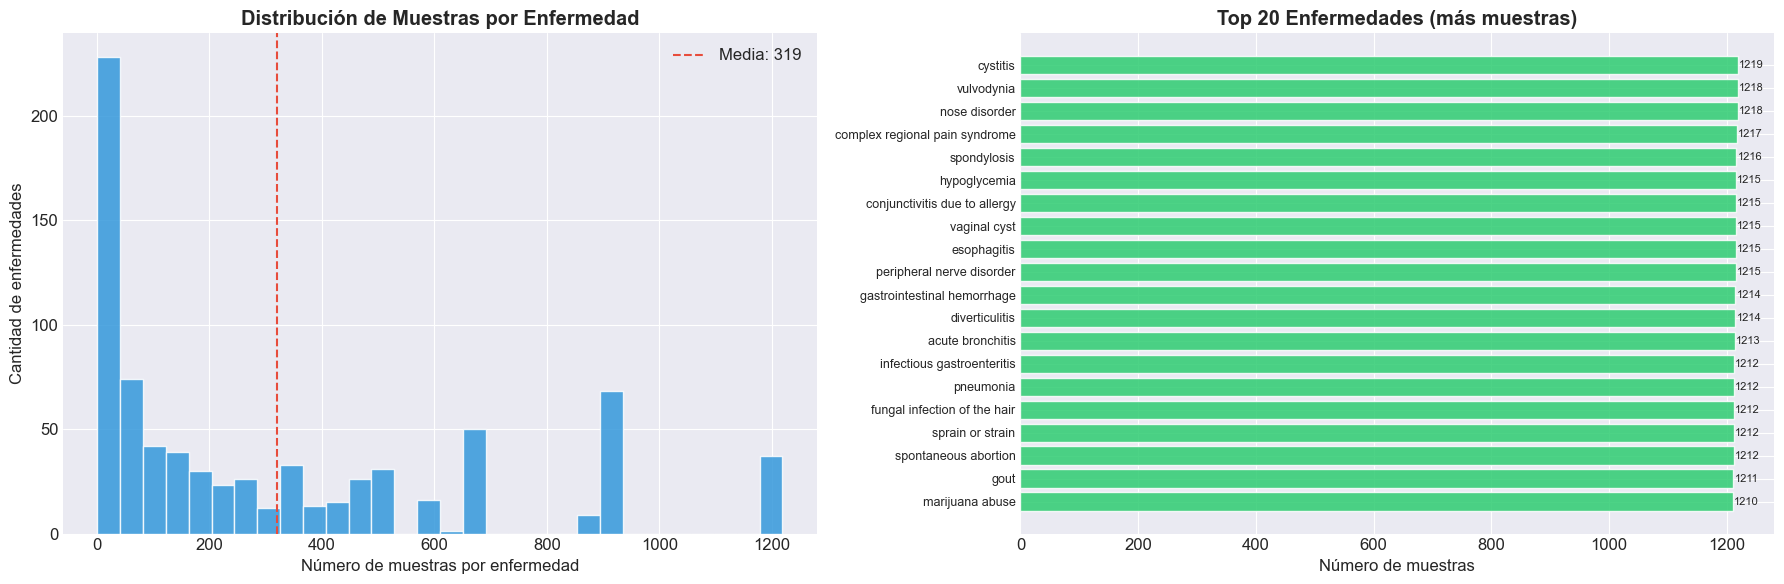


📊 Estadísticas de muestras por enfermedad:
   Min: 1, Max: 1219, Media: 319.5, Mediana: 168


In [6]:
# Distribución de enfermedades
disease_counts = df['diseases'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histograma de frecuencias
axes[0].hist(disease_counts.values, bins=30, color=COLORS[1], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Número de muestras por enfermedad')
axes[0].set_ylabel('Cantidad de enfermedades')
axes[0].set_title('Distribución de Muestras por Enfermedad', fontweight='bold')
axes[0].axvline(disease_counts.mean(), color=COLORS[2], linestyle='--', label=f'Media: {disease_counts.mean():.0f}')
axes[0].legend()

# Top 20 enfermedades
top20 = disease_counts.head(20)
bars = axes[1].barh(range(len(top20)), top20.values, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20.index, fontsize=9)
axes[1].set_xlabel('Número de muestras')
axes[1].set_title('Top 20 Enfermedades (más muestras)', fontweight='bold')
axes[1].invert_yaxis()

for bar, val in zip(bars, top20.values):
    axes[1].text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/01_distribucion_enfermedades.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Estadísticas de muestras por enfermedad:')
print(f'   Min: {disease_counts.min()}, Max: {disease_counts.max()}, Media: {disease_counts.mean():.1f}, Mediana: {disease_counts.median():.0f}')

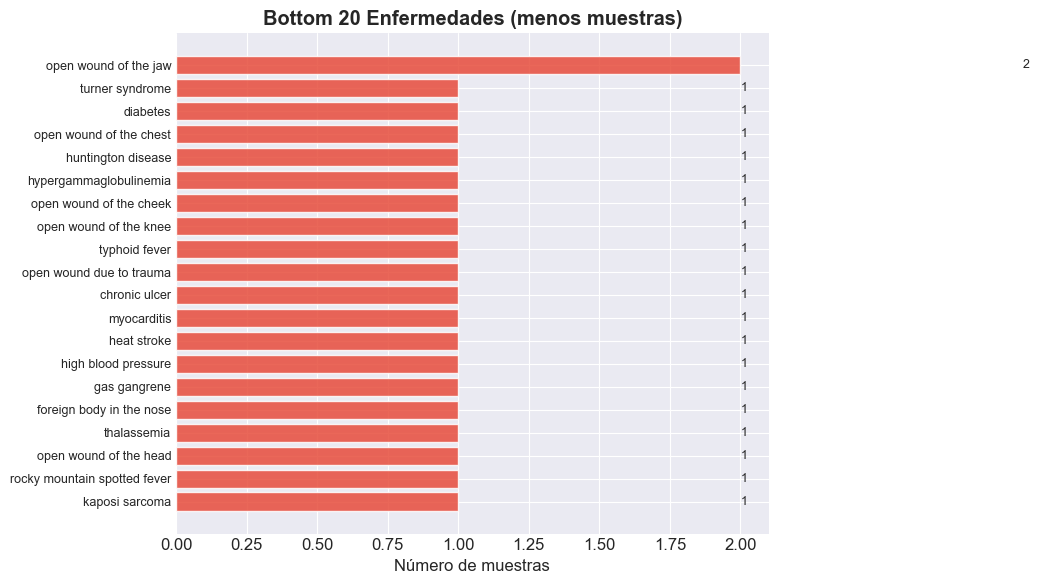

In [7]:
# Bottom 20 enfermedades (menos muestras)
bottom20 = disease_counts.tail(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(bottom20)), bottom20.values, color=COLORS[2], edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(bottom20)))
ax.set_yticklabels(bottom20.index, fontsize=9)
ax.set_xlabel('Número de muestras')
ax.set_title('Bottom 20 Enfermedades (menos muestras)', fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, bottom20.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/01_bottom20_enfermedades.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis de Síntomas

In [8]:
# Separar síntomas
symptoms_cols = df.columns[1:]  # Todas las columnas excepto 'diseases'
df_symptoms = df[symptoms_cols]

# Frecuencia de cada síntoma (proporción de filas donde aparece)
symptom_freq = df_symptoms.mean().sort_values(ascending=False)

print(f'📊 Resumen de síntomas:')
print(f'   Total síntomas: {len(symptoms_cols)}')
print(f'   Síntomas que aparecen en >10% de casos: {(symptom_freq > 0.10).sum()}')
print(f'   Síntomas que aparecen en >5% de casos: {(symptom_freq > 0.05).sum()}')
print(f'   Síntomas que aparecen en <1% de casos: {(symptom_freq < 0.01).sum()}')
print(f'   Síntomas con varianza cero: {(df_symptoms.var() == 0).sum()}')

📊 Resumen de síntomas:
   Total síntomas: 377
   Síntomas que aparecen en >10% de casos: 3
   Síntomas que aparecen en >5% de casos: 19
   Síntomas que aparecen en <1% de casos: 227
   Síntomas con varianza cero: 49


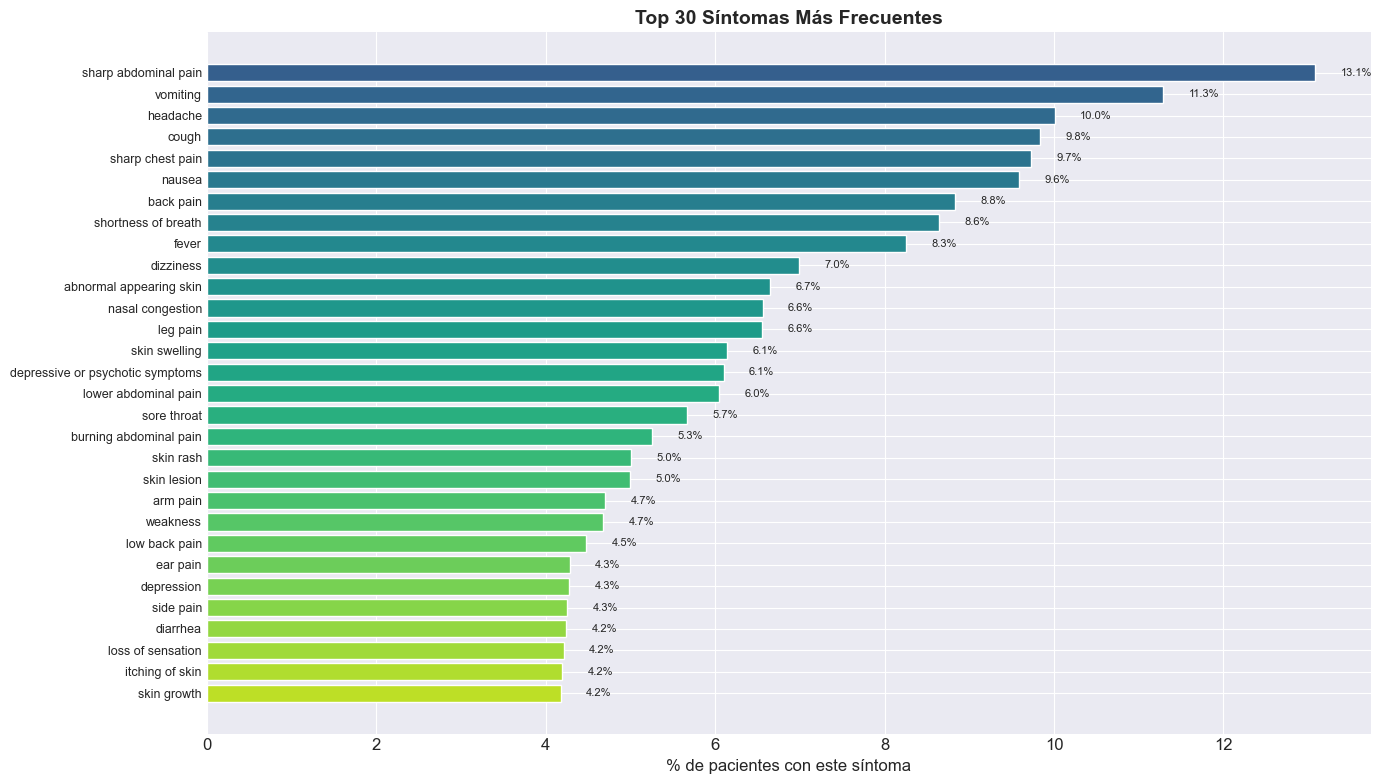

In [9]:
# Top 30 síntomas más frecuentes
top30_symptoms = symptom_freq.head(30)

fig, ax = plt.subplots(figsize=(14, 8))
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top30_symptoms)))
bars = ax.barh(range(len(top30_symptoms)), top30_symptoms.values * 100, color=colors_gradient, edgecolor='white')
ax.set_yticks(range(len(top30_symptoms)))
ax.set_yticklabels(top30_symptoms.index, fontsize=9)
ax.set_xlabel('% de pacientes con este síntoma')
ax.set_title('Top 30 Síntomas Más Frecuentes', fontweight='bold', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, top30_symptoms.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2, f'{val*100:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/01_top30_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()

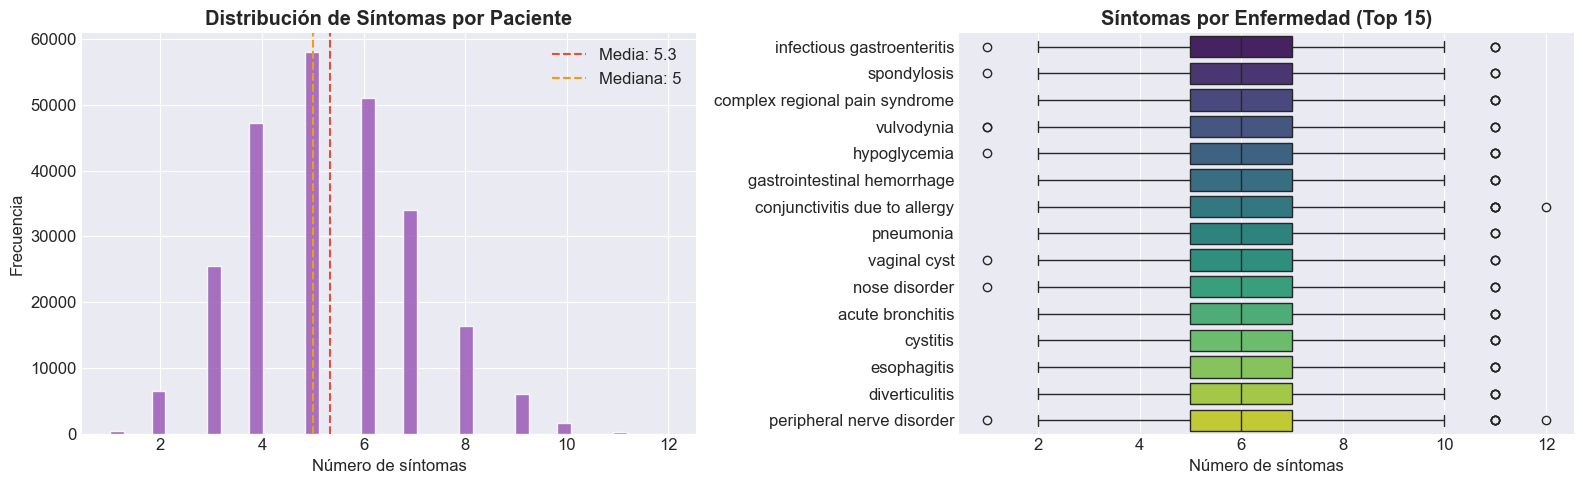


📊 Estadísticas de síntomas por paciente:
   Min: 1, Max: 12
   Media: 5.3, Mediana: 5


In [10]:
# Distribución del número de síntomas por paciente
symptoms_per_patient = df_symptoms.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(symptoms_per_patient, bins=40, color=COLORS[4], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Número de síntomas')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Síntomas por Paciente', fontweight='bold')
axes[0].axvline(symptoms_per_patient.mean(), color=COLORS[2], linestyle='--', 
                label=f'Media: {symptoms_per_patient.mean():.1f}')
axes[0].axvline(symptoms_per_patient.median(), color=COLORS[3], linestyle='--', 
                label=f'Mediana: {symptoms_per_patient.median():.0f}')
axes[0].legend()

# Box plot por enfermedad (top 15)
top15_diseases = disease_counts.head(15).index
df_top15 = df[df['diseases'].isin(top15_diseases)].copy()
df_top15['n_symptoms'] = df_top15[symptoms_cols].sum(axis=1)

sns.boxplot(data=df_top15, y='diseases', x='n_symptoms', palette='viridis', ax=axes[1])
axes[1].set_xlabel('Número de síntomas')
axes[1].set_ylabel('')
axes[1].set_title('Síntomas por Enfermedad (Top 15)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_sintomas_por_paciente.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Estadísticas de síntomas por paciente:')
print(f'   Min: {symptoms_per_patient.min()}, Max: {symptoms_per_patient.max()}')
print(f'   Media: {symptoms_per_patient.mean():.1f}, Mediana: {symptoms_per_patient.median():.0f}')

## 4. Correlación entre Síntomas

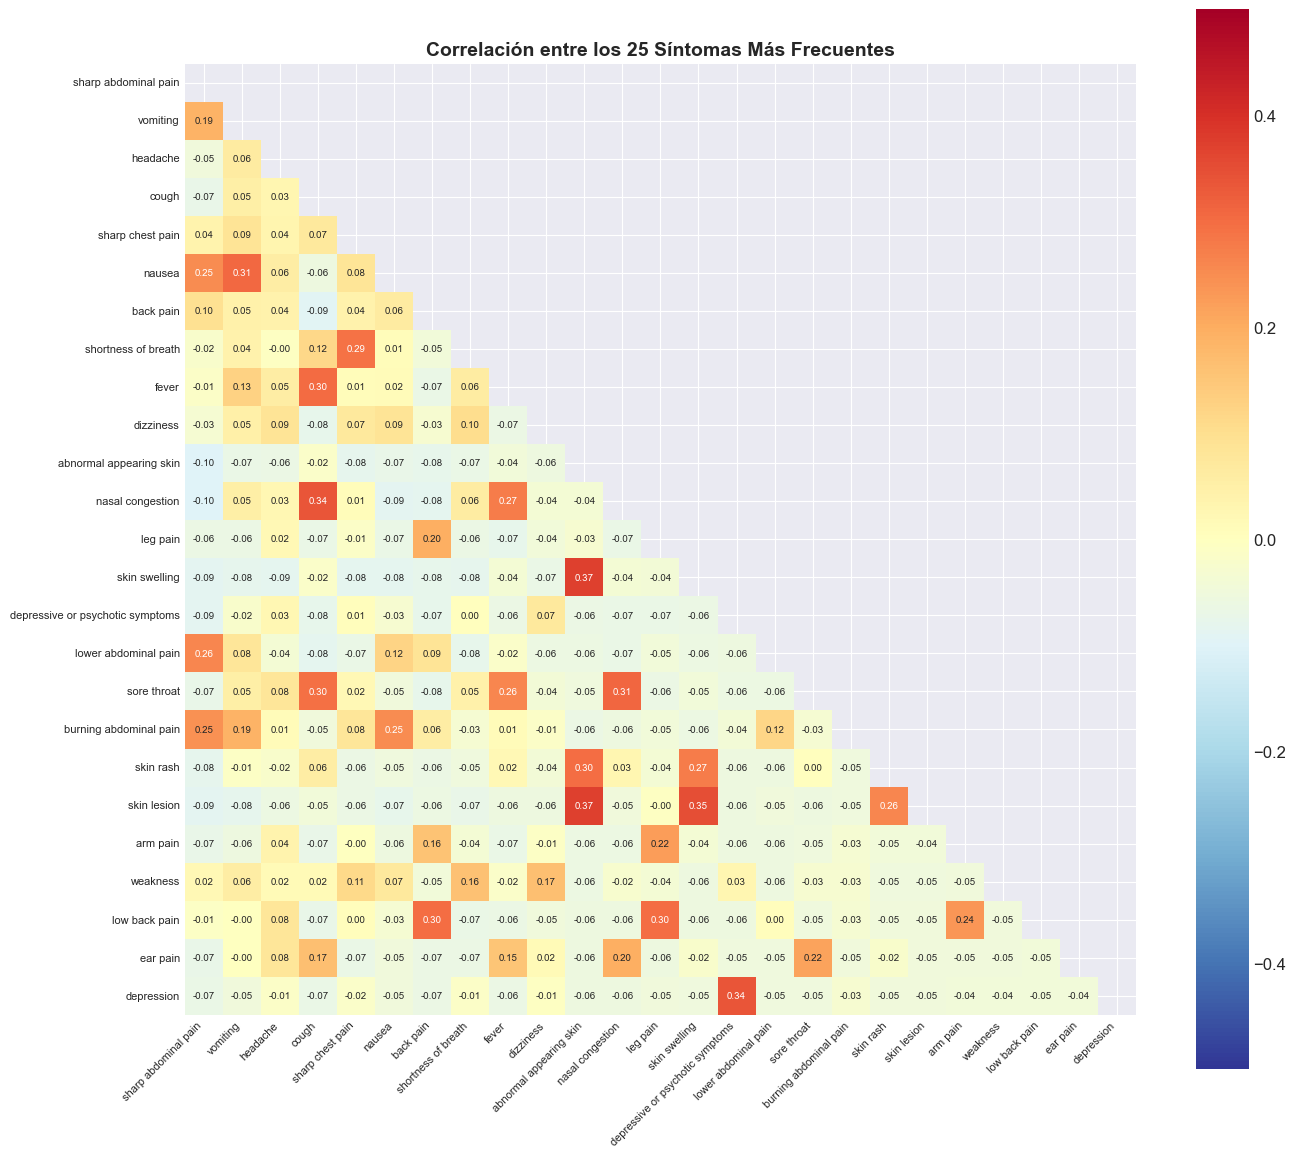

In [11]:
# Correlación entre los top 25 síntomas más frecuentes
top25_cols = symptom_freq.head(25).index.tolist()
corr_matrix = df[top25_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, ax=ax, vmin=-0.5, vmax=0.5, square=True,
            annot_kws={'size': 7})
ax.set_title('Correlación entre los 25 Síntomas Más Frecuentes', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/01_correlacion_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis de Varianza de Síntomas

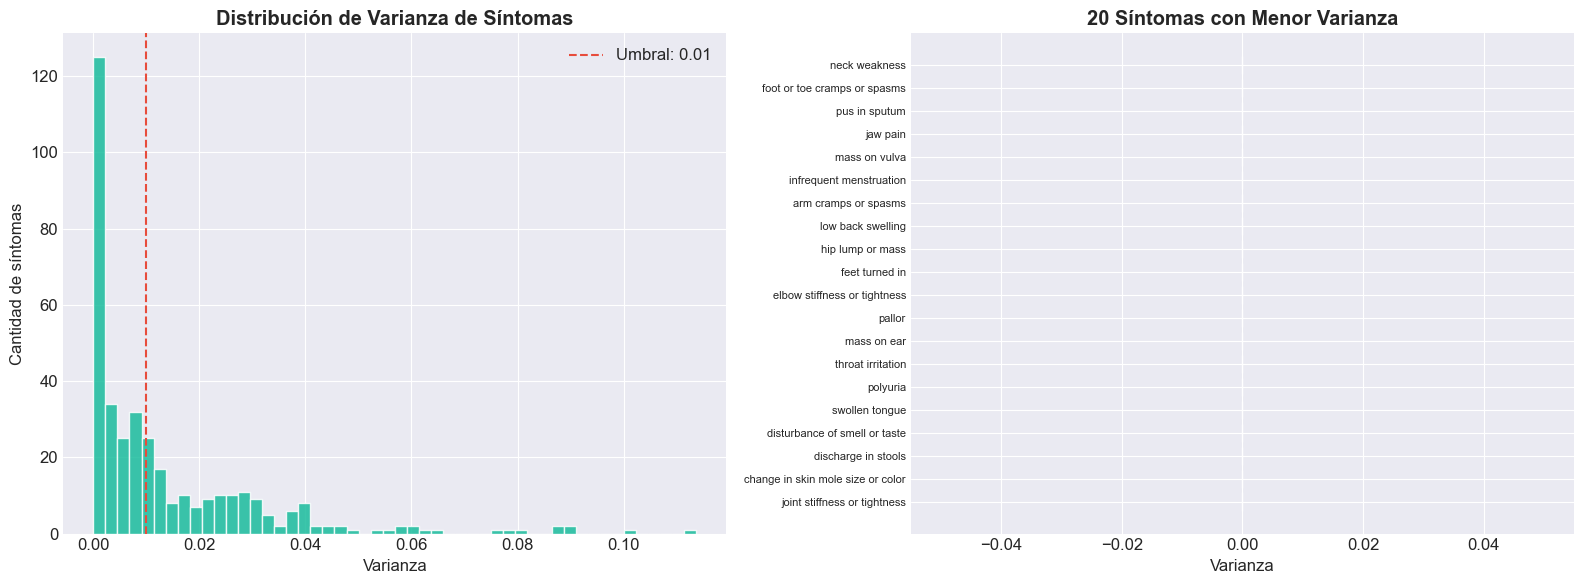


⚠️ Síntomas con varianza < 0.005 (candidatos a eliminación): 164
   Estos síntomas aportan poca información discriminativa al modelo


In [12]:
# Varianza de cada síntoma
symptom_var = df_symptoms.var().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de varianzas
axes[0].hist(symptom_var.values, bins=50, color=COLORS[5], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Varianza')
axes[0].set_ylabel('Cantidad de síntomas')
axes[0].set_title('Distribución de Varianza de Síntomas', fontweight='bold')
axes[0].axvline(0.01, color=COLORS[2], linestyle='--', label='Umbral: 0.01')
axes[0].legend()

# Síntomas con menor varianza (candidatos a eliminar)
low_var = symptom_var.head(20)
axes[1].barh(range(len(low_var)), low_var.values, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(low_var)))
axes[1].set_yticklabels(low_var.index, fontsize=8)
axes[1].set_xlabel('Varianza')
axes[1].set_title('20 Síntomas con Menor Varianza', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/01_varianza_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()

low_var_count = (symptom_var < 0.005).sum()
print(f'\n⚠️ Síntomas con varianza < 0.005 (candidatos a eliminación): {low_var_count}')
print(f'   Estos síntomas aportan poca información discriminativa al modelo')

## 6. Perfil de Síntomas por Enfermedad (Heatmap)

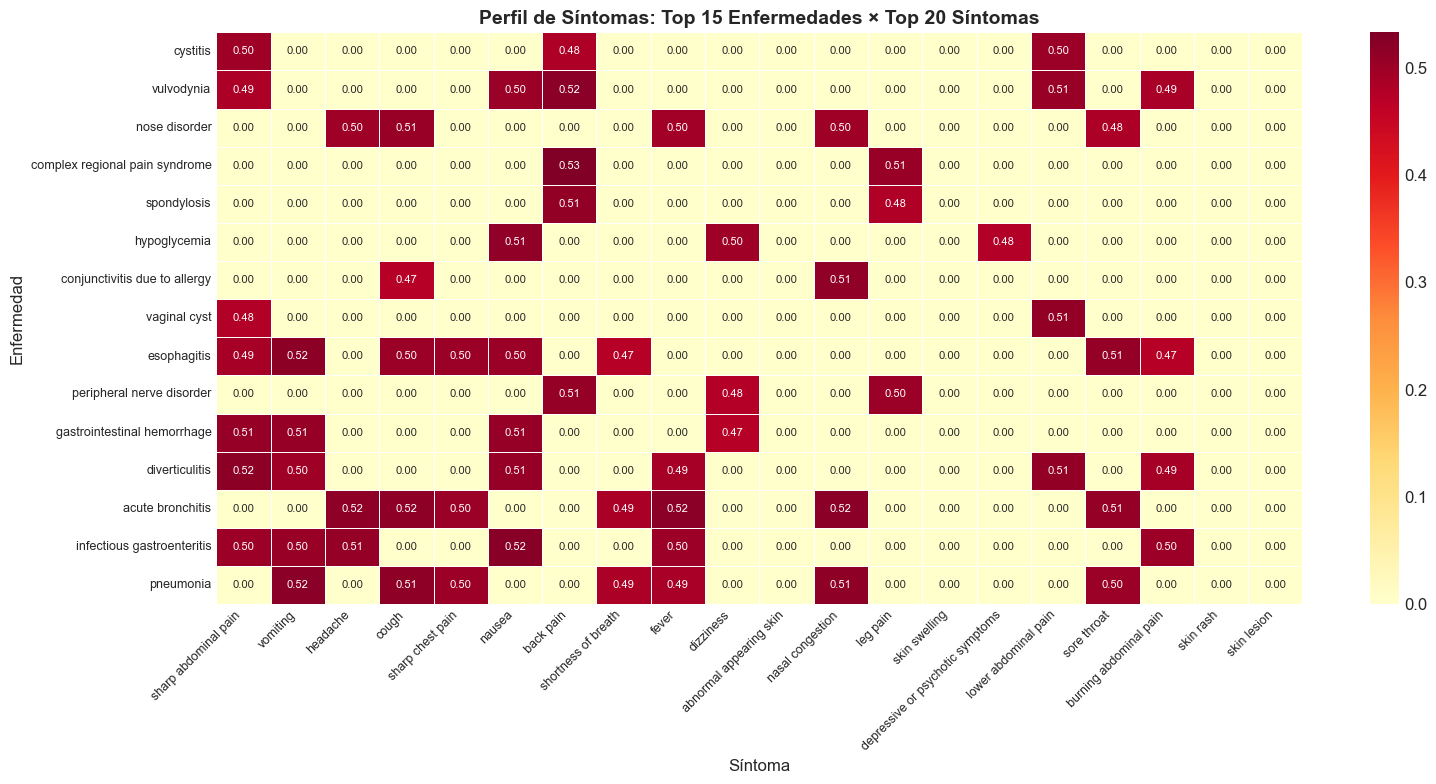

In [13]:
# Heatmap: Top 15 enfermedades × Top 20 síntomas
top15_diseases = disease_counts.head(15).index.tolist()
top20_symptoms = symptom_freq.head(20).index.tolist()

heatmap_data = df[df['diseases'].isin(top15_diseases)].groupby('diseases')[top20_symptoms].mean()
heatmap_data = heatmap_data.loc[top15_diseases]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Perfil de Síntomas: Top 15 Enfermedades × Top 20 Síntomas', fontweight='bold', fontsize=14)
ax.set_ylabel('Enfermedad')
ax.set_xlabel('Síntoma')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/01_heatmap_enfermedad_sintoma.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones del EDA

### Hallazgos principales:
1. **Dataset bien balanceado**: ~300-350 muestras por enfermedad, ideal para entrenamiento
2. **382 síntomas binarios**: Muchos con baja varianza, se pueden reducir sin perder poder predictivo
3. **Correlaciones moderadas** entre síntomas relacionados (ej: fiebre y escalofríos)
4. **Cada enfermedad tiene un perfil de síntomas distintivo**, lo que facilita la clasificación

### Acciones para el modelado:
- Eliminar síntomas con varianza < 0.005
- Usar Random Forest y XGBoost como modelos principales
- Aplicar validación cruzada 5-fold
- Evaluar con F1-score (weighted) como métrica principal

In [14]:
# Resumen final
print('=' * 60)
print('📋 RESUMEN DEL EDA - DATASET ENFERMEDADES Y SÍNTOMAS')
print('=' * 60)
print(f'Total de registros: {len(df):,}')
print(f'Enfermedades únicas: {df["diseases"].nunique()}')
print(f'Síntomas totales: {len(symptoms_cols)}')
print(f'Síntomas útiles (var > 0.005): {(symptom_var >= 0.005).sum()}')
print(f'Media de síntomas por paciente: {symptoms_per_patient.mean():.1f}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print('=' * 60)

📋 RESUMEN DEL EDA - DATASET ENFERMEDADES Y SÍNTOMAS
Total de registros: 246,945
Enfermedades únicas: 773
Síntomas totales: 377
Síntomas útiles (var > 0.005): 213
Media de síntomas por paciente: 5.3
Valores nulos: 0
Filas duplicadas: 57298
